# Práctica evaluación módulo 'Machine Learning y Deep Learning

## 0. Configuración Notebook

### Importación librerías

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.utils.validation import check_random_state
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from xgboost import XGBClassifier

### Definición constantes

In [4]:
DATA_DIR_RAW = '../../data/raw'

In [6]:
DATASET = f'{DATA_DIR_RAW}/dataset_practica_final.csv'
DATASET

'../../data/raw/dataset_practica_final.csv'

### Definición funciones

In [4]:
def compare_scores(model_list, y_test, X_test):
    '''
    muestra un dataframe con índice por modelo y columnas por métrica, valores el valor de la métrica
    '''
    pass

In [5]:
def plot_ROC(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo del ROC
    '''
    pass

In [6]:
def plot_confusion_matrix(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo de la confusion_matrix
    '''
    pass

## 1. Carga y pre-procesamiento de datos

### Carga y copia

In [7]:
df = pd.read_csv(DATASET)
df_cp = df.copy()

In [6]:
df_cp.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Inspección

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
df_cp.shape

(119390, 32)

In [9]:
# Tipos de datos
# 12 columnas son srt
# 16 columnas son int64
# 4 columnas son float64

In [10]:
# Valores nulos
df_cp.isna().sum()[df_cp.isna().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [11]:
df_cp.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
# Elimino características directamente relacionadas con la variable objetivo

In [ ]:
# Descartar las características irrelevantes

In [12]:
df = pd.read_csv(DATASET)

In [15]:
# reservatiobn_status está directamente ligada a is_canceled
# Nos da el valor de la variable objetivo (fuga de datos)

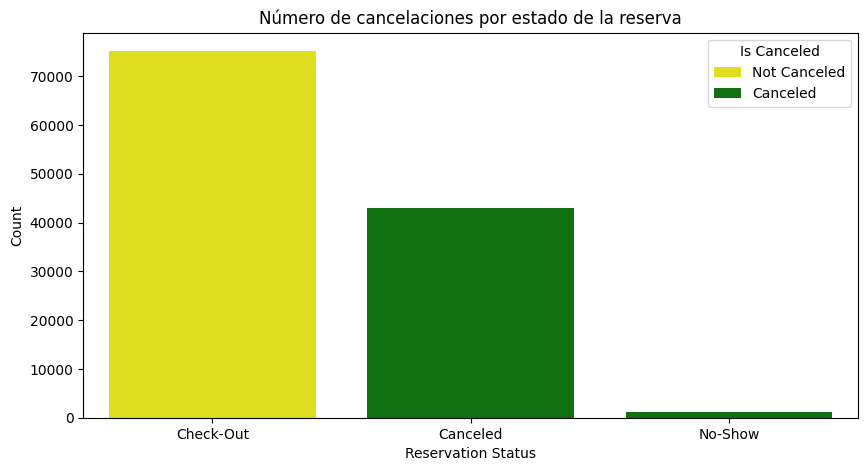

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x='reservation_status', hue='is_canceled', data=df, palette=['yellow', 'green'])
plt.title('Número de cancelaciones por estado de la reserva')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

In [14]:
df.groupby('reservation_status')['is_canceled'].mean()

reservation_status
Canceled     1.0
Check-Out    0.0
No-Show      1.0
Name: is_canceled, dtype: float64

In [16]:
# Todas las reservar con un reservation_status de "Canceled" o "No-Show" son efectivamente canceladas

In [15]:
# Se elimina
df = df.drop(['reservation_status'], axis=1)

In [16]:
# Lo mismo para 'reservation_status_date'
df = df.drop(['reservation_status_date'], axis=1)

In [ ]:
df['arrival_date_year'].value_counts()

In [17]:
# 'assigned_room_type' es irrelevante porque se asigna después de hacer la reserva. No se puede usar para predecir
df = df.drop(['assigned_room_type'], axis=1)

In [18]:
#'arrival_date_year' Solo incluye algunos años. Haría sesgar el modelo a años específicos
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [19]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [22]:
df = df.drop(['arrival_date_year'], axis=1)

In [ ]:
# Ver la cardinalidad de diferentes columnas
alta_cardinalidad = ['country', 'agent', 'company']

In [24]:
unicas_categorias = df[alta_cardinalidad].nunique()
valores_faltantes = df[alta_cardinalidad].isnull().sum()

alta_cardinalidad_df = pd.DataFrame({'Unicas_Categorias': unicas_categorias,'Valores_Faltantes': valores_faltantes})

alta_cardinalidad_df

,Unicas_Categorias,Valores_Faltantes
country,177,488
agent,333,16340
company,352,112593


In [25]:
top_countries = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')

In [26]:
# Simplificar Agente y Compañía a variables binarias
df['has_company'] = df['company'].notnull().astype(int)
df['has_agent'] = df['agent'].notnull().astype(int)
df.drop(['company', 'agent'], axis=1, inplace=True)

In [27]:
# Calcular el porcentaje de valores faltantes en el conjunto de datos original
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
missing_values_percentage[missing_values_percentage > 0]

children    0.00335
dtype: float64

In [28]:
df['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [29]:
df['children'] = df['children'].fillna(df['children'].median())

In [30]:
df['children'].value_counts()

children
0.0     110800
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [31]:
datos_ruidosos = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10]
}

datos_ruidosos = {key: len(value) for key, value in datos_ruidosos.items()}
datos_ruidosos

{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [ ]:
# Hay 1 reserva con una Tasa Diaria Promedio (ADR) negativa. No tiene sentido
# Hay 403 reservas con 0 adultos
# Hay 1 reserva con 10 niños
# Hay 1 reserva con 1 bebe

In [32]:
# Reemplazar el valor negativo por la mediana
df.loc[df['adr'] < 0, 'adr'] = df['adr'].median()

In [33]:
# Eliminar las columnas con 0 adultos
df = df[df['adults'] != 0]

In [34]:
# Eliminar las filas con 10 niños y 10 bebes
df = df[df['children'] != 10]
df = df[df['babies'] != 10]

In [35]:
datos_ruidosos_modificados = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10]
}

numero_datos_ruidosos_modificados = {key: len(value) for key, value in datos_ruidosos_modificados.items()}
numero_datos_ruidosos_modificados

{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

In [36]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
booking_changes                     int64
deposit_type                          str
days_in_waiting_list                int64
customer_type                         str
adr                               

In [37]:
#Balanceamiento de is_canceled
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.924738
1    37.075262
Name: proportion, dtype: float64

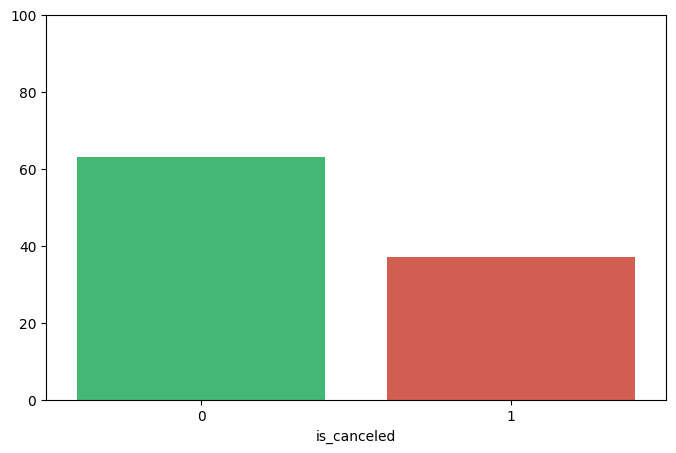

In [38]:
#Balanceamiento de is_canceled
porcentajes = df['is_canceled'].value_counts(normalize=True) * 100

# Tamaño
plt.figure(figsize=(8, 5))

#Gráfico de barras
ax = sns.barplot(
    x=porcentajes.index, 
    y=porcentajes.values, 
    palette=['#2ecc71', '#e74c3c'],
    hue=porcentajes.index,
    legend=False
)

plt.ylim(0, 100)

plt.show()

In [ ]:
# El 37.07% de las reservas fueron canceladas
# El 62.92% no fueron canceladas

# Hay un poco de balanceo, de desequilibrio en el target. Pero no muy desequilibrado.
# No hay que aplicar técnicas de muestreo

In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 118985 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118985 non-null  str    
 1   is_canceled                     118985 non-null  int64  
 2   lead_time                       118985 non-null  int64  
 3   arrival_date_month              118985 non-null  str    
 4   arrival_date_week_number        118985 non-null  int64  
 5   arrival_date_day_of_month       118985 non-null  int64  
 6   stays_in_weekend_nights         118985 non-null  int64  
 7   stays_in_week_nights            118985 non-null  int64  
 8   adults                          118985 non-null  int64  
 9   children                        118985 non-null  float64
 10  babies                          118985 non-null  int64  
 11  meal                            118985 non-null  str    
 12  country                         

In [8]:
def loader(dataset_csv_filename:str, OHE:bool) -> (pd.core.frame.DataFrame, pd.core.frame.DataFrame, pd.core.series.Series, pd.core.series.Series):
    '''
    dataset_csv_filename: ruta al csv con los datos
    OHE: si es true, los campos categóricos se condifican con OneHotEncoder. 
         si false los campos de texto se codifican a categoría y después a numérico usando sus códigos
    '''
    # se setea random_state para que los resultados sean predecibles (que el resultado sea el mismo siempre)
    check_random_state(42)

    # carga del csv en un dataframe
    dset = pd.read_csv(DATASET)
    
    # Eliminación de variables con fugas de datos (Data Leakage)
    columns_to_drop =[
                        'reservation_status',
                        'reservation_status_date',
                        'arrival_date_year',
                        'assigned_room_type']
    dset.drop(columns_to_drop, axis= 1, inplace=True)

    # --- LIMPIEZA DE ANOMALÍAS ---
    
    # Reemplazar el valor negativo por la mediana
    dset.loc[dset['adr'] < 0, 'adr'] = dset['adr'].median()

    # Eliminar las columnas con 0 adultos
    dset = dset[dset['adults'] != 0]

    # Eliminar las filas con 10 niños y 10 bebes
    dset = dset[dset['children'] != 10]
    dset = dset[dset['babies'] != 10]

    # --- LIMPIEZA DE ANOMALÍAS ---


    # Agrupar países con poca representación
    top_countries = dset['country'].value_counts().nlargest(10).index
    dset['country'] = dset['country'].where(dset['country'].isin(top_countries), 'Other')

    # Convertir el mes a valor numérico para mantener la temporalidad
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    dset['arrival_date_month'] = dset['arrival_date_month'].map(month_map)

    # Simplificar Agente y Compañía a variables binarias
    dset['has_company'] = dset['company'].notnull().astype(int)
    dset['has_agent'] = dset['agent'].notnull().astype(int)
    dset.drop(['company', 'agent'], axis=1, inplace=True)
    
    # relleno de los valores faltantes
    dset['children'] = dset['children'].fillna(dset['children'].median())

    # separación en target (variable objetivo) y features
    X = dset.drop(['is_canceled'], axis=1)
    y = dset['is_canceled']

    # train_test_split se hace antes de trasnformar nada
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    

    # OneHot encoder de las variables categóricas (no ordinales) y standa
    list_one_hot_cols = []
    if OHE:
        list_one_hot_cols = [
                            'hotel',
                            'meal',
                            'country',
                            'market_segment',
                            'distribution_channel',
                            #'is_repeated_guest',
                            'reserved_room_type',
                            #'assigned_room_type',
                            'deposit_type',
                            #'agent',
                            #'company',
                            'customer_type']
    else:
        # primero se ponen en una lista los cmps de texto
        # sdespués se convierten los campos a catgorías, se toman sus códigos numéricos (.cat.codes) y se sustitye a los string originales por ellos
        # text_fields = [c for c in X.columns if X[c].dtype==object
        text_fields = [c for c in X_train.columns if X_train[c].dtype==object]
        for c in text_fields:
            X_train[c] = X_train[c].astype('category').cat.codes
            X_test[c] = X_test[c].astype('category').cat.codes  

    # Mejor hacer la lista dinámica, para que no se pierda nada
    list_numeric_cols = [col for col in X_train.columns if col not in list_one_hot_cols]

    columns_preprocessor = ColumnTransformer(transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), list_one_hot_cols),
        #('ordinal', OrdinalEncoder(), list_ordinal_cols),
        ('numeric', MinMaxScaler(), list_numeric_cols)
    ])

    # columns_preprocessor.fit_transform(X_test)
    # fit_transform solo en train, transform en test
    X_train_processed = columns_preprocessor.fit_transform(X_train)
    X_test_processed = columns_preprocessor.transform(X_test)

    # Restaurar a DataFrame para no perder los nombres
    nombres_columnas = columns_preprocessor.get_feature_names_out()

    # Se limpia el texto que añade scikit-learn por defecto
    nombres_columnas = [nombre.replace('one_hot__', '').replace('numeric__', '') for nombre in nombres_columnas]

    X_train = pd.DataFrame(X_train_processed, columns=nombres_columnas, index=X_train.index)
    X_test = pd.DataFrame(X_test_processed, columns=nombres_columnas, index=X_test.index)

    return (X_train, X_test, y_train, y_test)

### *Cosas a ver*:
- si está balanceado
- identificar outlayers
- identificar datos faltantes
- sacar correlaciones
- sacar pca 


## 2. Entrenamiento (incluye selección de hiperparámetros)

### 2.1 Logistic Regression

In [9]:
X_train, X_test, y_train, y_test = loader(DATASET, OHE=True)

In [10]:
# PROBAR EN /PREDICT
import json
import pandas as pd
# Extraer el cliente de prueba
cliente_prueba = X_test.iloc[0:1].to_dict(orient="records")
json_completo = json.dumps({"datos": cliente_prueba})

print(json_completo)

{"datos": [{"hotel_Resort Hotel": 1.0, "meal_FB": 0.0, "meal_HB": 0.0, "meal_SC": 0.0, "meal_Undefined": 0.0, "country_BRA": 0.0, "country_DEU": 0.0, "country_ESP": 0.0, "country_FRA": 0.0, "country_GBR": 0.0, "country_IRL": 0.0, "country_ITA": 0.0, "country_NLD": 0.0, "country_Other": 1.0, "country_PRT": 0.0, "market_segment_Complementary": 0.0, "market_segment_Corporate": 0.0, "market_segment_Direct": 0.0, "market_segment_Groups": 0.0, "market_segment_Offline TA/TO": 1.0, "market_segment_Online TA": 0.0, "market_segment_Undefined": 0.0, "distribution_channel_Direct": 0.0, "distribution_channel_GDS": 0.0, "distribution_channel_TA/TO": 1.0, "distribution_channel_Undefined": 0.0, "reserved_room_type_B": 0.0, "reserved_room_type_C": 0.0, "reserved_room_type_D": 1.0, "reserved_room_type_E": 0.0, "reserved_room_type_F": 0.0, "reserved_room_type_G": 0.0, "reserved_room_type_H": 0.0, "reserved_room_type_L": 0.0, "deposit_type_Non Refund": 0.0, "deposit_type_Refundable": 0.0, "customer_type_G

In [11]:
# Máximo de iteraciones para que es enúmero de iteraciones trate de encontrar los parámetros que mejor convergen con la
#fórmula de la regresión logística.
modelo_rl = LogisticRegression(max_iter=500, random_state=42) 
modelo_rl.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [12]:
param_grid_rl = {
    # Probar regularización L1 (Lasso) y L2 (Ridge)
    'penalty': ['l2'],
    # Fuerza de la regularización
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    # Algoritmo de optimización que soporta penalizaciones l1 y l2
    'solver': ['liblinear'] 
}

In [13]:
def optimizar_hiperparametros_modelo(modelo_base, cuadricula_parametros, X_train, y_train, metrica_evaluacion='f1', n_splits=5):
    
    #Creamos una validacion cruzada usando "StratifiedKFold" para asegurarnos que la distribucion de clases es la misma en todos los segmentos
    cross_validation = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    #Creamos GridSearchCv, para saber los mejores hiperparámetros para mi modelo
    buscador_gridsearch = GridSearchCV(modelo_base, cuadricula_parametros, cv=cross_validation, scoring=metrica_evaluacion, n_jobs=-1)
    
    #Ajustamos el GridSearch a los datos de entrenamiento
    buscador_gridsearch.fit(X_train, y_train)
    
    #Seleccionamos los mejores hiperparametros
    mejores_hiperparametros = buscador_gridsearch.best_params_
    
    #Retornamos los mejores estimadores que nos da el modelo con los datos de entrenamiento ajustados
    
    return buscador_gridsearch.best_estimator_, mejores_hiperparametros

In [14]:
mejor_rl, hiperparametros_rl = optimizar_hiperparametros_modelo(
    modelo_rl, 
    param_grid_rl, 
    X_train, 
    y_train
)

print('\n¡Optimización terminada!')
print('Los mejores parámetros encontrados son:\n', hiperparametros_rl)

c:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



¡Optimización terminada!
Los mejores parámetros encontrados son:
 {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


In [15]:
def metrics_calculator(clf, X_test, y_test, model_name):
    
    '''
    Esta funcion calcula las medidas de performance para un modelo dado segun el conjunto de datos.
    Las metricas son especificamente calculadas para la clase 1
    '''
    
    y_pred = clf.predict(X_test)
    result = pd.DataFrame(data=[accuracy_score(y_test, y_pred),
                                precision_score(y_test, y_pred, pos_label=1),
                                recall_score(y_test, y_pred, pos_label=1),
                                f1_score(y_test, y_pred, pos_label=1),
                                roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])],
                          index=['Accuracy','Precision (Class 1)','Recall (Class 1)','F1-score (Class 1)','AUC (Class 1)'],
                          columns = [model_name])
    
    result = (result * 100).round(2).astype(str) + '%'                            
    return result  

In [16]:
def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    '''
    Esta funcion nos dara un reporte completo de la performance del modelo incluyendo el repote de clasificación
    matrix de confusion y curva ROC '''
    
    sns.set(font_scale=1.2)
    
    #Generamos el reporte de clasificación para el conjunto de entrenamiento.
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-"*55)
    print(classification_report(y_train, y_pred_train))
    
    #Generamos el reporte de clasificación para el conjunto de prueba
    y_pred_test = clf.predict(X_test)
    print("\n\t   Classification report for test set")
    print("-"*55)
    print(classification_report(y_test, y_pred_test))
    
    
    #Creamos un grafico
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]})
    
    #Definimos un mapa de color
    royalblue = LinearSegmentedColormap.from_list('royalblue', [(0, (1,1,1)), (1, (0.25,0.41,0.88))])
    royalblue_r = royalblue.reversed()
    
    #Graficamos la matrix de confusion para el conjunto de prueba
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')                                     
    ax1.grid(False)
    
    #Graficamos la curva ROC para el conjunto de prueba y el puntaje AUC
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')
    
    #Reporte de resultados para la clase especifica positiva
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(cellText=result.values, colLabels=result.columns, rowLabels=result.index, loc='center')
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')
    
    #Modificamos el color
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')
    plt.tight_layout()
    plt.show() 


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     59897
           1       0.72      0.76      0.74     35291

    accuracy                           0.80     95188
   macro avg       0.79      0.79      0.79     95188
weighted avg       0.80      0.80      0.80     95188


	   Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     14974
           1       0.72      0.77      0.74      8823

    accuracy                           0.80     23797
   macro avg       0.79      0.80      0.79     23797
weighted avg       0.81      0.80      0.80     23797



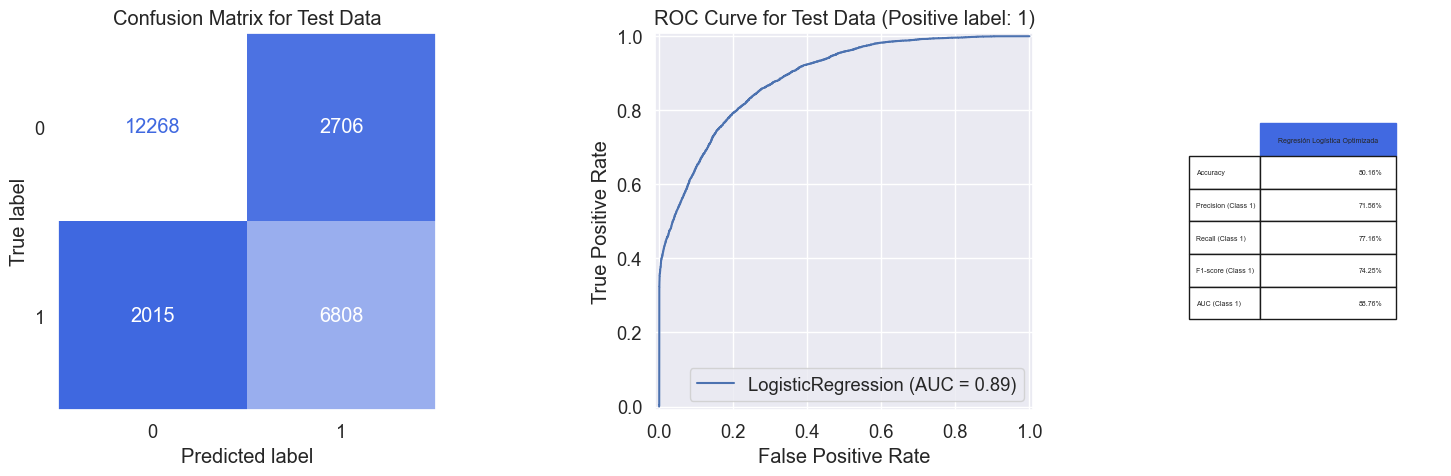

In [17]:
model_evaluation(mejor_rl, X_train, X_test, y_train, y_test, 'Regresión Logística Optimizada')

In [18]:
#Guardamos las metricas principales de modelo de clasificación
lr_results = metrics_calculator(mejor_rl, X_test, y_test, 'Logistic Regression')
lr_results

,Logistic Regression
Accuracy,80.16%
Precision (Class 1),71.56%
Recall (Class 1),77.16%
F1-score (Class 1),74.25%
AUC (Class 1),88.76%


In [19]:
# Preddicción del modelo
y_pred = modelo_rl.predict(X_test)

In [20]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.8027902676808001


In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm

array([[13596,  1378],
       [ 3315,  5508]])

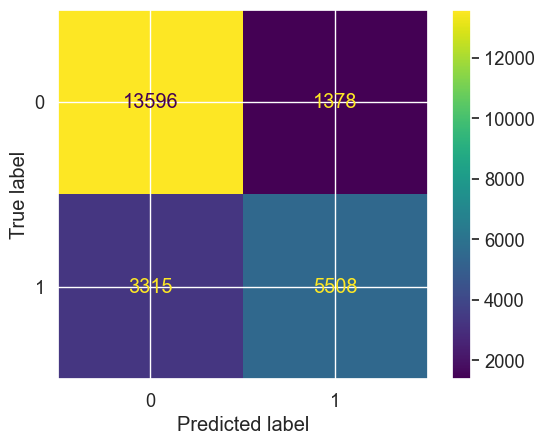

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### 2.2 DecisionTree

In [23]:
X_train, X_test, y_train, y_test = loader(DATASET, OHE=True)

In [24]:
dt_base = DecisionTreeClassifier(random_state=0)

In [ ]:
# Los falsos positivos (reserva se predice como cancelada, pero no lo es), como los falsos negativos
#(una reserva se predice como no cancelada, pero lo es), son perjudiciales para el hotel ($)

# Es más importante minimizar los falsos negativos (son más costosos).
# Enfoque: Maximizar la recuperación para la clase 'cancelada' (1).

In [25]:
def optimizar_hiperparametros_modelo(modelo_base, cuadricula_parametros, X_train, y_train, metrica_evaluacion='f1', n_splits=5):
    
    #Creamos una validacion cruzada usando "StratifiedKFold" para asegurarnos que la distribucion de clases es la misma en todos los segmentos
    cross_validation = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    #Creamos GridSearchCv, para saber los mejores hiperparámetros para mi modelo
    buscador_gridsearch = GridSearchCV(modelo_base, cuadricula_parametros, cv=cross_validation, scoring=metrica_evaluacion, n_jobs=-1)
    
    #Ajustamos el GridSearch a los datos de entrenamiento
    buscador_gridsearch.fit(X_train, y_train)
    
    #Seleccionamos los mejores hiperparametros
    mejores_hiperparametros = buscador_gridsearch.best_params_
    
    #Retornamos los mejores estimadores que nos da el modelo con los datos de entrenamiento ajustados
    
    return buscador_gridsearch.best_estimator_, mejores_hiperparametros

In [26]:
# Diccionario de hiperparámetros para el modelo
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None], # El None dice que pruebe a crecer sin límites a ver que pasa
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': [None, 'balanced'] # el algoritmo calcula matemáticamente la proporción exacta del dataset y equilibra los pesos a la perfección.
}
# (2 x 4 x 3 x 3 x 2) son 144 combinaciones diferentes de árboles.
# Con n_splits=5 prueba cada una de estas 144 combinaciones 5 veces diferentes

In [27]:
#Ejecutamos la función
mejor_arbol, mejores_hiperparametros_arbol = optimizar_hiperparametros_modelo(dt_base, param_grid_dt, X_train, y_train)
print('DT Optimal Hyperparameters: \n', mejores_hiperparametros_arbol)

DT Optimal Hyperparameters: 
 {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
""" RESULTADO:
DT Optimal Hyperparameters: 
 {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
"""

"""
'class_weight': 'balanced' --> El algoritmo ha decidido que la mejor forma de acertar es dándole más peso matemático
a las cancelaciones para no pasarlas por alto.
'max_depth': 15 --> El árbol ha tenido que hacer hasta 15 preguntas seguidas (profundidad de 15 niveles) para separar
a los clientes.
'min_samples_leaf': 1, 'min_samples_split': 2 --> El árbol ha exprimido los datos al máximo, creando ramas incluso si
solo le quedaban 2 clientes por clasificar, creando hojas con 1 solo cliente.
"""

In [28]:
# Evaluación del modelo:

def metrics_calculator(clf, X_test, y_test, model_name):
    
    '''
    Esta funcion calcula las medidas de performance para un modelo dado segun el conjunto de datos.
    Las metricas son especificamente calculadas para la clase 1
    '''
    
    y_pred = clf.predict(X_test)
    result = pd.DataFrame(data=[accuracy_score(y_test, y_pred),
                                precision_score(y_test, y_pred, pos_label=1),
                                recall_score(y_test, y_pred, pos_label=1),
                                f1_score(y_test, y_pred, pos_label=1),
                                roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])],
                          index=['Accuracy','Precision (Class 1)','Recall (Class 1)','F1-score (Class 1)','AUC (Class 1)'],
                          columns = [model_name])
    
    result = (result * 100).round(2).astype(str) + '%'                            
    return result  

In [29]:
def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    '''
    Esta funcion nos dara un reporte completo de la performance del modelo incluyendo el repote de clasificación
    matrix de confusion y curva ROC '''
    
    sns.set(font_scale=1.2)
    
    #Generamos el reporte de clasificación para el conjunto de entrenamiento.
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-"*55)
    print(classification_report(y_train, y_pred_train))
    
    #Generamos el reporte de clasificación para el conjunto de prueba
    y_pred_test = clf.predict(X_test)
    print("\n\t   Classification report for test set")
    print("-"*55)
    print(classification_report(y_test, y_pred_test))
    
    
    #Creamos un grafico
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]})
    
    #Definimos un mapa de color
    royalblue = LinearSegmentedColormap.from_list('royalblue', [(0, (1,1,1)), (1, (0.25,0.41,0.88))])
    royalblue_r = royalblue.reversed()
    
    #Graficamos la matrix de confusion para el conjunto de prueba
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')                                     
    ax1.grid(False)
    
    #Graficamos la curva ROC para el conjunto de prueba y el puntaje AUC
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')
    
    #Reporte de resultados para la clase especifica positiva
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(cellText=result.values, colLabels=result.columns, rowLabels=result.index, loc='center')
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')
    
    #Modificamos el color
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')
    plt.tight_layout()
    plt.show() 


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     59897
           1       0.79      0.87      0.83     35291

    accuracy                           0.87     95188
   macro avg       0.85      0.87      0.86     95188
weighted avg       0.87      0.87      0.87     95188


	   Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     14974
           1       0.75      0.83      0.79      8823

    accuracy                           0.83     23797
   macro avg       0.82      0.83      0.83     23797
weighted avg       0.84      0.83      0.84     23797



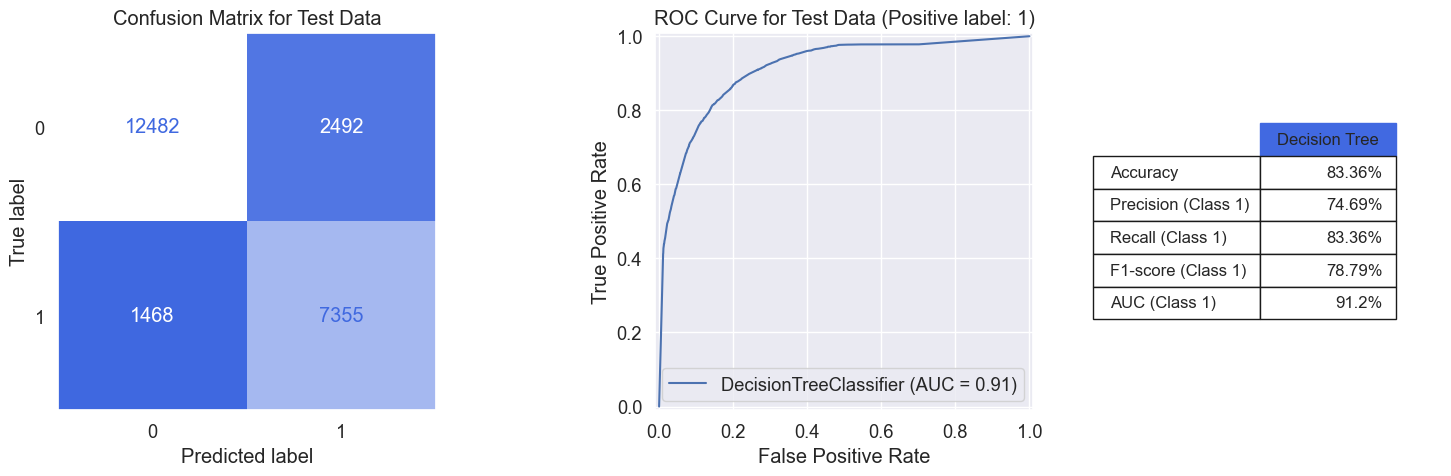

In [30]:
model_evaluation(mejor_arbol, X_train, X_test, y_train, y_test, 'Decision Tree')

In [31]:
#Guardamos las metricas principales de modelo de clasificación
dt_results = metrics_calculator(mejor_arbol, X_test, y_test, 'Decision_Tree')
dt_results

,Decision_Tree
Accuracy,83.36%
Precision (Class 1),74.69%
Recall (Class 1),83.36%
F1-score (Class 1),78.79%
AUC (Class 1),91.2%


### 2.3 Random Forest

### 2.4 XGBoost

In [32]:
X_train, X_test, y_train, y_test = loader(DATASET, OHE=True)

In [33]:
# Calcular el peso matemático del desbalanceo para las cancelaciones (Imprescindible para un buen Recall)
total_negativos = (y_train == 0).sum()
total_positivos = (y_train == 1).sum()
peso_cancelaciones = total_negativos / total_positivos

print(f"Peso calculado para XGBoost (scale_pos_weight): {peso_cancelaciones:.2f}")

Peso calculado para XGBoost (scale_pos_weight): 1.70


In [34]:
# Definir el modelo
xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_cancelaciones,
    eval_metric='logloss'
)

In [35]:
# Diseñar el Grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

In [36]:
# Uso la funciónn para buscar los mejores hiperparámetros
mejor_xgb, hiperparametros_xgb = optimizar_hiperparametros_modelo(
    xgb_base, 
    param_grid_xgb, 
    X_train, 
    y_train
)

print("\nEntrenando XGBoost... (Esto puede tardar unos minutos)")
print('\n¡Entrenamiento terminado!')
print('Mejores hiperparámetros:', hiperparametros_xgb)


Entrenando XGBoost... (Esto puede tardar unos minutos)

¡Entrenamiento terminado!
Mejores hiperparámetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [37]:
def metrics_calculator(clf, X_test, y_test, model_name):
    
    '''
    Esta funcion calcula las medidas de performance para un modelo dado segun el conjunto de datos.
    Las metricas son especificamente calculadas para la clase 1
    '''
    
    y_pred = clf.predict(X_test)
    result = pd.DataFrame(data=[accuracy_score(y_test, y_pred),
                                precision_score(y_test, y_pred, pos_label=1),
                                recall_score(y_test, y_pred, pos_label=1),
                                f1_score(y_test, y_pred, pos_label=1),
                                roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])],
                          index=['Accuracy','Precision (Class 1)','Recall (Class 1)','F1-score (Class 1)','AUC (Class 1)'],
                          columns = [model_name])
    
    result = (result * 100).round(2).astype(str) + '%'                            
    return result  

In [38]:
def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    '''
    Esta funcion nos dara un reporte completo de la performance del modelo incluyendo el repote de clasificación
    matrix de confusion y curva ROC '''
    
    sns.set(font_scale=1.2)
    
    #Generamos el reporte de clasificación para el conjunto de entrenamiento.
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-"*55)
    print(classification_report(y_train, y_pred_train))
    
    #Generamos el reporte de clasificación para el conjunto de prueba
    y_pred_test = clf.predict(X_test)
    print("\n\t   Classification report for test set")
    print("-"*55)
    print(classification_report(y_test, y_pred_test))
    
    
    #Creamos un grafico
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]})
    
    #Definimos un mapa de color
    royalblue = LinearSegmentedColormap.from_list('royalblue', [(0, (1,1,1)), (1, (0.25,0.41,0.88))])
    royalblue_r = royalblue.reversed()
    
    #Graficamos la matrix de confusion para el conjunto de prueba
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')                                     
    ax1.grid(False)
    
    #Graficamos la curva ROC para el conjunto de prueba y el puntaje AUC
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')
    
    #Reporte de resultados para la clase especifica positiva
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(cellText=result.values, colLabels=result.columns, rowLabels=result.index, loc='center')
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')
    
    #Modificamos el color
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')
    plt.tight_layout()
    plt.show() 


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     59897
           1       0.85      0.91      0.88     35291

    accuracy                           0.91     95188
   macro avg       0.90      0.91      0.90     95188
weighted avg       0.91      0.91      0.91     95188


	   Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     14974
           1       0.80      0.86      0.83      8823

    accuracy                           0.87     23797
   macro avg       0.86      0.86      0.86     23797
weighted avg       0.87      0.87      0.87     23797



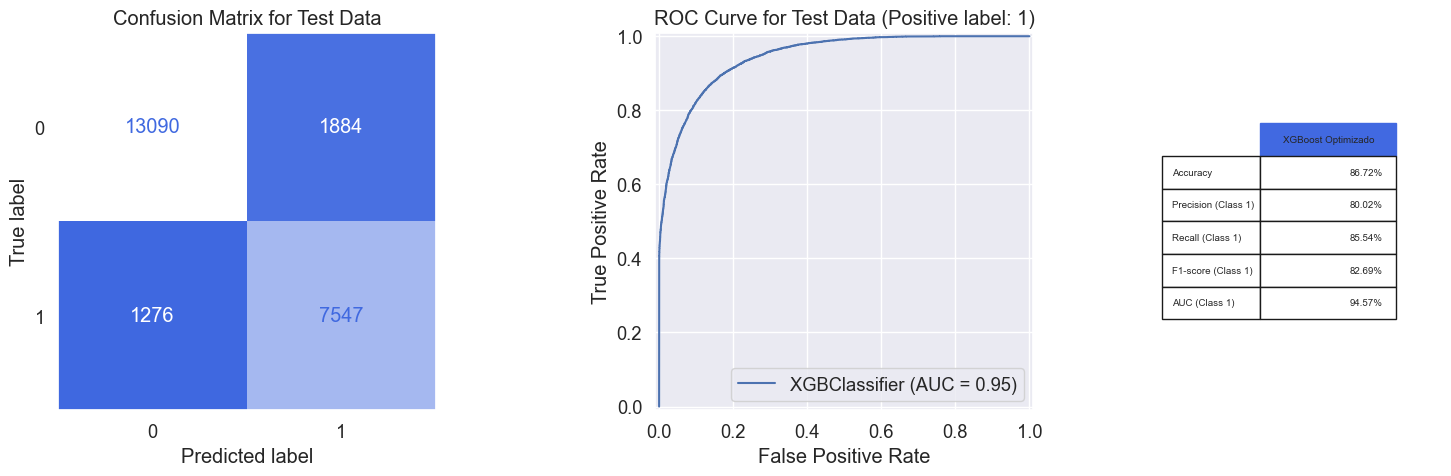

In [39]:
# Evaluar los resultados
model_evaluation(mejor_xgb, X_train, X_test, y_train, y_test, 'XGBoost Optimizado')

In [40]:
#Guardamos las metricas principales del modelo de clasificación
xgb_results = metrics_calculator(mejor_xgb, X_test, y_test, 'XGBoost')
xgb_results

,XGBoost
Accuracy,86.72%
Precision (Class 1),80.02%
Recall (Class 1),85.54%
F1-score (Class 1),82.69%
AUC (Class 1),94.57%


### 2.5 Multilayer Neural Network

## 3. Comparativa Modelos